### Vaginal Birth After C-Section Data Exploration

Cesarean sections (coloquially known as c-sections) are the most common surgical procedure performed worldwide, but it is not always the desired outcome for birthing parents. Many people giving birth again after a previous c-section seek to achieve vaginal birth after c-section, also known as VBAC.

This project seeks to determine what factors most correlate with successful VBAC, and to create prediction models from that data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# suppress warnings
import warnings

warnings.filterwarnings("ignore")

In [2]:
raw_df = pd.read_parquet("../../../data/processed/natality_2021_numeric.parquet")

Because we are only interested in birthing parents who have had a previous c-section, we will use a subset of our dataset and filter out those who have not had a c-section.

In [3]:
df = raw_df.loc[raw_df["previous_cesarean"] == 1].copy()

We are left with a dataframe with 562,593 rows and 228 columns.

In [4]:
df.shape

(562593, 227)

The delivery method is recorded in `delivery_method_recode_7` with the following possible outcomes:

1. Vaginal (excludes vaginal after previous C-section)
2. Vaginal after previous c-section
3. Primary C-section
4. Repeat C-section
5. Vaginal (unknown if previous c-section)
6. C-section (unknown if previous c-section)
9. Not stated

We can see that the majority of birthing parents (85.8%) in our dataset will have a repeat c-section, leaving the remaining 14.2% as those who successfully achieved VBAC.

In [5]:
df["delivery_method_recode_7"].value_counts(normalize=True)

delivery_method_recode_7
4    0.858205
2    0.141566
9    0.000229
Name: proportion, dtype: float64

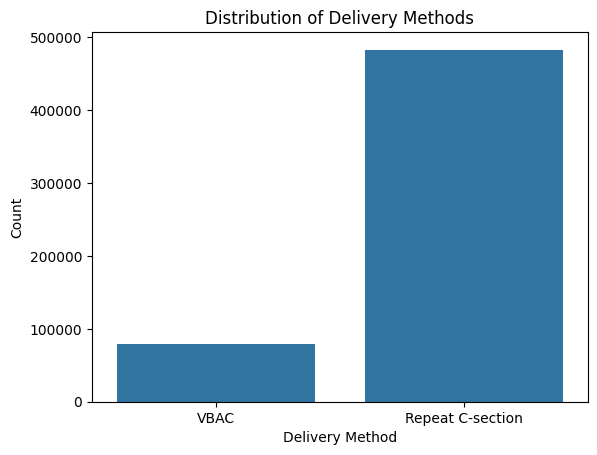

In [12]:
delivery_method_value_counts = df["delivery_method_recode_7"].value_counts()
delivery_method_value_counts = delivery_method_value_counts.drop(9)

delivery_method_bar_ax = sns.barplot(
    x=delivery_method_value_counts.index,
    y=delivery_method_value_counts.values,
)
delivery_method_bar_ax.set_title("Distribution of Delivery Methods")
delivery_method_bar_ax.set_xlabel("Delivery Method")
delivery_method_bar_ax.set_ylabel("Count")
delivery_method_bar_ax.set_xticklabels(
    [
        "VBAC",
        "Repeat C-section",
    ]
)
plt.show()

In [ ]:
from pickle import dump

dump(df, open("../../../data/interim/vbac/vbac_df.pkl", "wb"))